In [1]:
from neuromaps import NeuroMapManuscript

model = NeuroMapManuscript.load("checkpoints/model.ckpt")

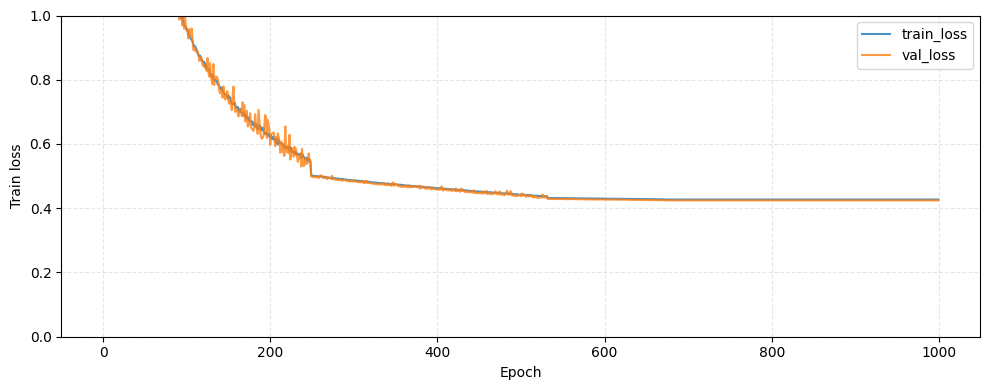

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use('default')
mpl.rcdefaults()

hist = model.training_history

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(np.arange(len(hist["train_loss"])), hist["train_loss"],
        label="train_loss", lw=1.5, alpha=.8)
ax.plot(np.arange(len(hist["val_loss"])), hist["val_loss"],
        label="val_loss", lw=1.5, alpha=.8)


ax.set_xlabel(f"Epoch")
ax.set_ylabel("Train loss")
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, ls="--", alpha=.3)
plt.tight_layout()
plt.show()

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 29126.40шаг/s]


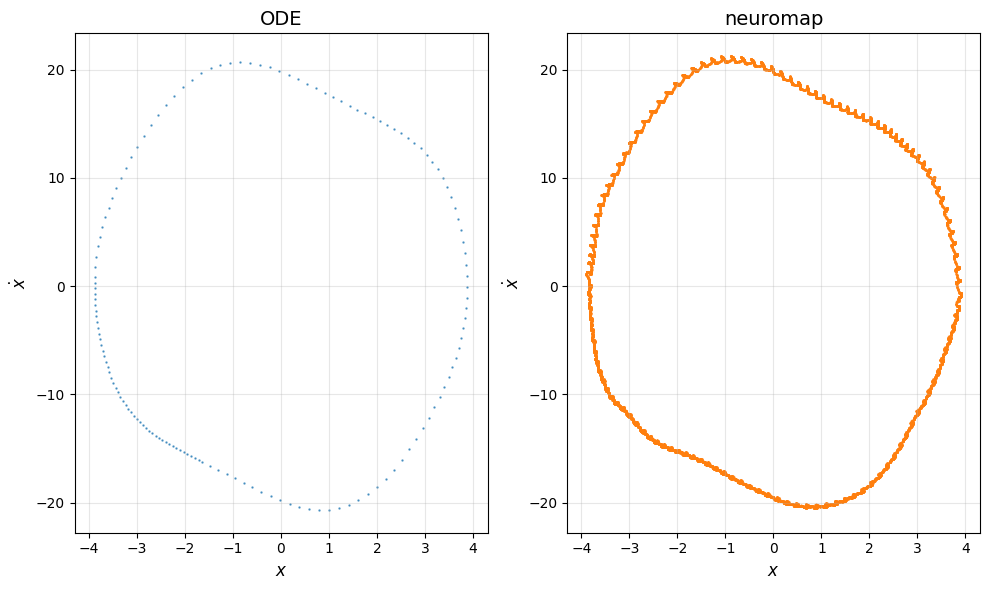

In [3]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import vdp_mod1_rk4, vdp_mod1_right_part

u0 = [5, -50]
p = [-1.78, 0.07]

ode_traj = get_attractor_trajectory(vdp_mod1_rk4, vdp_mod1_right_part, 
                                    u0, p, 0.01, 300, 200, lambda x, y: x[1],
                                    lambda x, y: [0, 1], divergence_threshold=1e3)
nm_traj = model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)

if nm_traj is not None:
    nm_traj = nm_traj[1000:]
if ode_traj is not None:
    ode_traj = ode_traj[100:]

plot_compare_trajectories(ode_traj, nm_traj, labels=['ODE', 'neuromap'], layout='sidebyside')

In [19]:
from utils import grid_of_amplitude_basin_over_initial_state
from systems import vdp_mod1_rk4
import numpy as np

# Общие условия для ODE и Neuromap (сравнение карт — при одинаковом расчёте амплитуды)
p_fixed = [-1.78, 0.07]
u0_base = [0.0, 0.0]
dt = 0.01
n_transient = 20
n_attractor = 20
divergence_threshold = 1e3  # как в ячейке с траекториями

x_grid = np.linspace(-10, 10, 20)
y_grid = np.linspace(-10, 10, 20)
x_state_index, y_state_index = 0, 1

# ODE: по умолчанию ode_amplitude_mode="integrated" — та же схема, что у Neuromap (не секущая Пуанкаре)
Z_ode, div_ode = grid_of_amplitude_basin_over_initial_state(
    evolution_operator=vdp_mod1_rk4,
    state=u0_base,
    params=p_fixed,
    dt=dt,
    n_transient=n_transient,
    n_attractor=n_attractor,
    x_grid=x_grid,
    y_grid=y_grid,
    x_state_index=x_state_index,
    y_state_index=y_state_index,
    divergence_threshold=divergence_threshold,
)

Z_nm, div_nm = grid_of_amplitude_basin_over_initial_state(
    evolution_operator=vdp_mod1_rk4,
    state=u0_base,
    params=p_fixed,
    dt=dt,
    n_transient=n_transient,
    n_attractor=n_attractor,
    x_grid=x_grid,
    y_grid=y_grid,
    x_state_index=x_state_index,
    y_state_index=y_state_index,
    model=model,
    divergence_threshold=divergence_threshold,
)


Симуляция: 100%|██████████████████████████████████████████████| 100/100 [00:00<00:00, 22187.39шаг/s]

Симуляция: 100%|███████████████████████████████████████████████| 100/100 [00:00<00:00, 7277.99шаг/s]

Симуляция: 100%|██████████████████████████████████████████████| 100/100 [00:00<00:00, 15840.71шаг/s]

Симуляция: 100%|███████████████████████████████████████████████| 100/100 [00:00<00:00, 9542.05шаг/s]

Симуляция: 100%|███████████████████████████████████████████████| 100/100 [00:00<00:00, 8279.48шаг/s]

Симуляция: 100%|██████████████████████████████████████████████| 100/100 [00:00<00:00, 10077.37шаг/s]

Симуляция: 100%|███████████████████████████████████████████████| 100/100 [00:00<00:00, 7865.25шаг/s]

Симуляция: 100%|███████████████████████████████████████████████| 100/100 [00:00<00:00, 9553.79шаг/s]

Симуляция: 100%|██████████████████████████████████████████████| 100/100 [00:00<00:00, 12109.67шаг/s]

Симуляция: 100%|███████████████████████████████████████████████| 100/100 [00:00<00

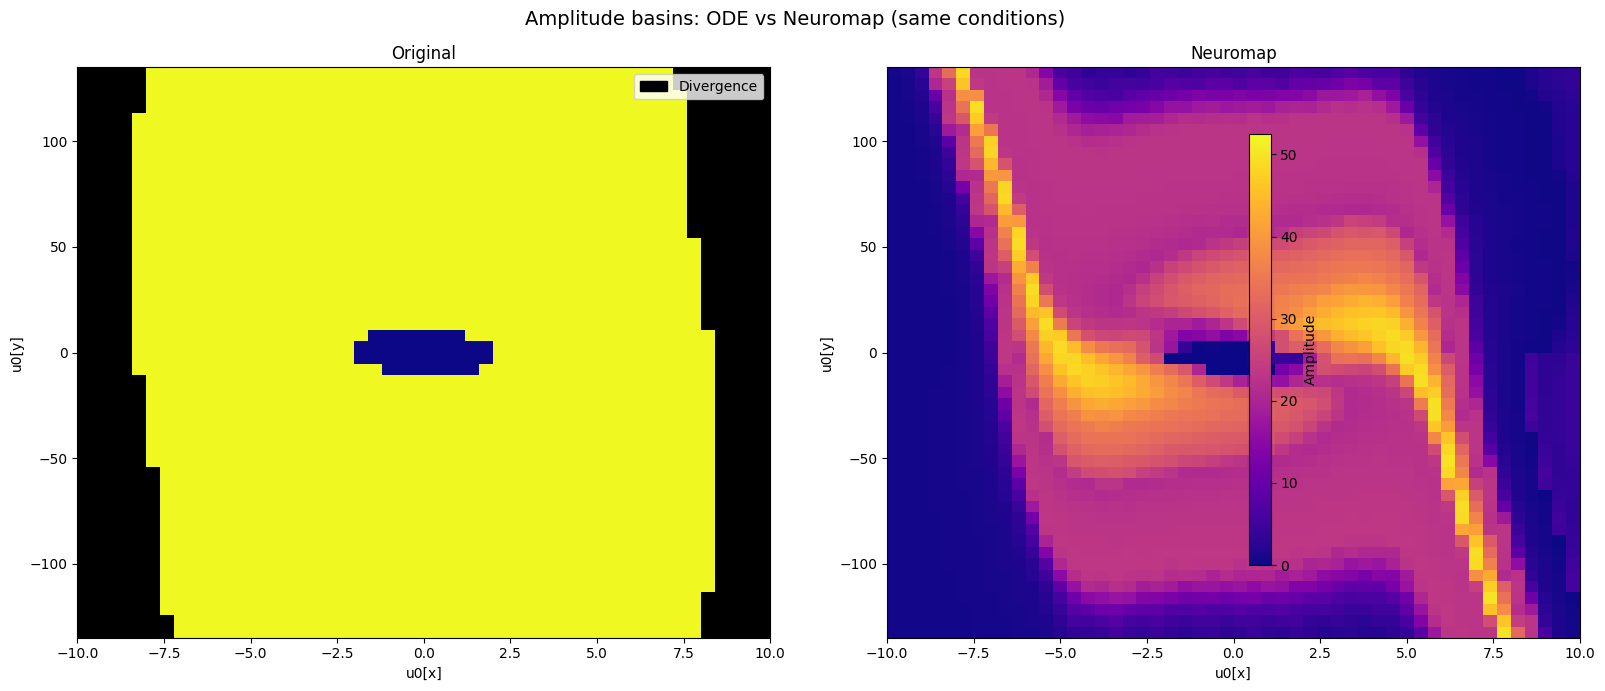

In [20]:
from utils import plot_amplitude_basin, plot_compare_amplitude_basins

plot_compare_amplitude_basins(
    x_grid,
    y_grid,
    Z_ode,
    Z_nm,
    caption='Amplitude basins: ODE vs Neuromap (same conditions)',
    x_label='u0[x]',
    y_label='u0[y]',
    cmap='plasma',
    bad_color='black',
)